Assessment For Neural Network Regression using TensorFlow

1.Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it.

2.Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?

3.Try and improve the results.

4.Create the plot between predict and actual values.

Please do not use exact same example as RegressionExample3.
Upload your Google Colab Notebook to GitHub.

In [94]:
import numpy as np, tensorflow as tf,matplotlib.pyplot as plt, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [95]:
data=pd.read_csv('/content/sample_data/student_classifier_v3.csv')
data

,StudyHours,Attendance,PreviousScore,Score
0,2,60,40,40
1,4,70,50,52
2,6,80,60,65
3,8,90,75,81
4,10,95,85,90
5,1,55,35,20
6,5,75,55,60
7,7,85,70,73
8,9,92,88,92
9,3,65,45,50


In [96]:
X=data.drop('Score',axis=1)
y=data['Score']

In [97]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [98]:
#Model Creation
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1)
])

In [99]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.mse,
    metrics=["mae"]
)

In [100]:
history=model.fit(X_train,y_train,epochs=100,
                  validation_data=(X_test,y_test),verbose=0)

In [101]:
loss,mae=model.evaluate(X_test,y_test,verbose=0)
print(f"MAE :{mae}")

MAE :6.040720462799072


In [102]:
y_pred=model.predict(X_test)
print(y_test.values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
[50 96 40]


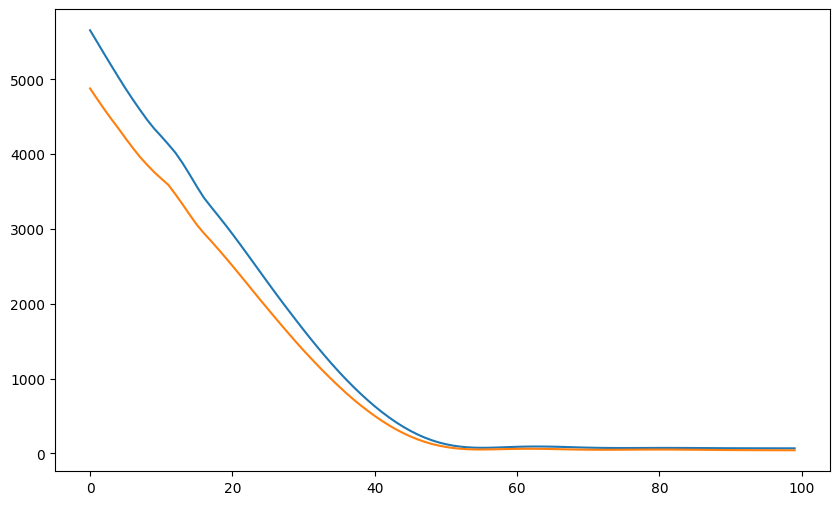

In [103]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


Text(0.5, 1.0, 'Actual vs Predict')

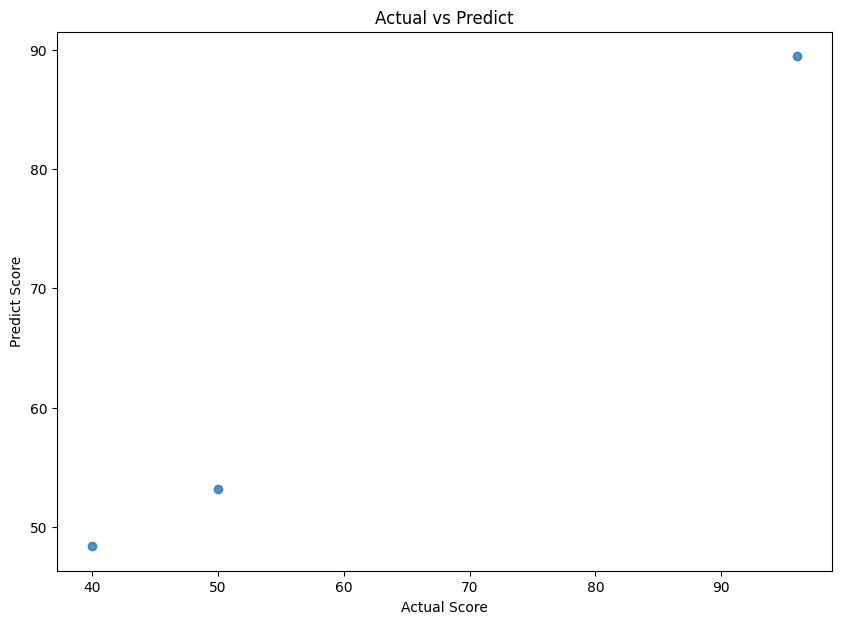

In [104]:
y_pred=model.predict(X_test)
plt.figure(figsize=(10,7))
plt.scatter(y_test,y_pred,alpha=0.8)
plt.xlabel('Actual Score')
plt.ylabel('Predict Score')
plt.title('Actual vs Predict')